# **MAT 4373: Project** </br> L1 vs. L2 regularization
Here we will be investigating the behaviour of regularization (L1 and L2 regularization) in a non ideal theoretical space. We will see how lasso and ridge regression behave under highly correlated datasets.

### **Dataset: A correlated Gaussian design**
We generate synthetic data using the same sparse linear model:

y = Xw* + ε

However, unlike Dataset 1, we introduce correlation among features:

- X ~ N(0, Σ), where Σ is a covariance matrix,
- w* is sparse,
- ε ~ N(0, σ²).

To model correlation, we use a Toeplitz covariance structure:
Σ_{jk} = ρ^{|j-k|}

This means nearby features are more strongly correlated.

**Goal**  
We investigate:
- whether Lasso’s variable selection deteriorates under correlated predictors,
- whether Ridge provides more stable estimates in the presence of correlation.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, Ridge
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.metrics import mean_squared_error, f1_score
from sklearn.model_selection import train_test_split
from data_generation import generate_sparse_linear_data
from data_generation import generate_correlated_sparse_linear_data

#### **Experiment 1: Effects of Correlation**

We will observe different generated datasets with different levels of correlation [0, 0.3, 0.5, 0.7] to see how our models respond in an environment where our ideal assumptions are not met.


c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.731e-01, tolerance: 4.744e-02
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.947e-01, tolerance: 2.488e-02
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, che

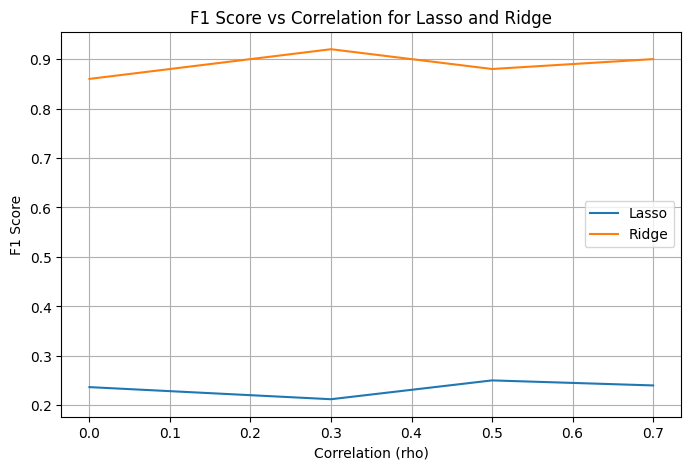

In [7]:
rho_values=[0, 0.3, 0.5, 0.7]

num_trials = 10

results = {
    "rho": [],
    "lasso_f1": [],
    "ridge_f1": []
}

threshold = 1e-3 #threshold to determine nonzero coefficients for recall calculation 

for rho in rho_values:
    lasso_f1s = []
    ridge_f1s = []
    for seed in range(num_trials):
        X_corr,y_corr,w_true_corr,support_corr,Sigma=generate_correlated_sparse_linear_data(rho=rho, n=100, d=50, s=5, sigma=1.5, signal=1.0, random_seeds=seed)

        true_support = np.zeros(len(w_true_corr), dtype=int)
        true_support[support_corr] = 1
    
        X_train, X_test, y_train, y_test = train_test_split(
            X_corr, y_corr, test_size=0.3, random_state=seed
        )
        
        # Lasso
        lasso = LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1, 10])
        lasso.fit(X_train, y_train)
        lasso_support = (lasso.coef_ > 1e-3).astype(int)
        lasso_f1 = f1_score(true_support, lasso_support)
        lasso_f1s.append(lasso_f1)
        
        # Ridge
        ridge = RidgeCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1, 10])
        ridge.fit(X_train, y_train)
        k = np.sum(true_support)

        ridge_topk = np.argsort(np.abs(ridge.coef_))[-k:]
        ridge_support = np.zeros_like(true_support)
        ridge_support[ridge_topk] = 1

        ridge_f1 = f1_score(true_support, ridge_support)
        ridge_f1s.append(ridge_f1)

    results["rho"].append(rho)
    results["lasso_f1"].append(np.mean(lasso_f1s))
    results["ridge_f1"].append(np.mean(ridge_f1s))

plt.figure(figsize=(8, 5))
plt.plot(results["rho"], results["lasso_f1"], label="Lasso")
plt.plot(results["rho"], results["ridge_f1"], label="Ridge")

plt.xlabel("Correlation (rho)")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Correlation for Lasso and Ridge")

plt.legend()
plt.grid(True)
plt.show()

We can see that correlation pretty much breaks lasso, while ridge regression does much better

#### **Experiment 2: The effects of noise on prediction**

We want to observe how noise affects our lasso and ridge regression prediction score. We will vary the noise greatly and determine how our model predicts.

c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.533e-01, tolerance: 8.520e-02
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.753e-01, tolerance: 8.935e-02
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, che

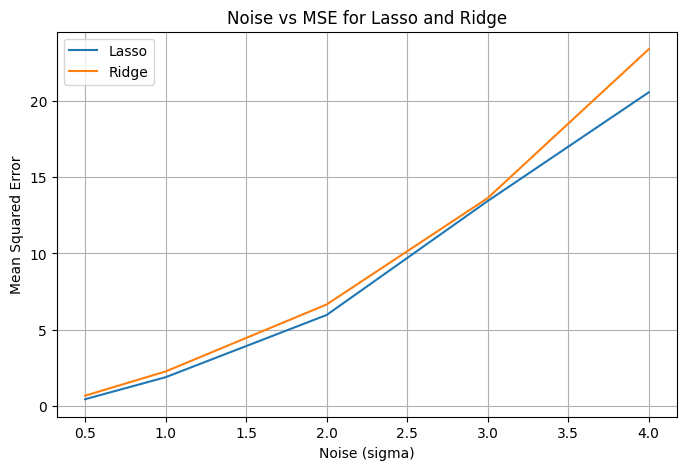

In [8]:
sigma_values = [0.5, 1.0, 2.0, 3.0, 4.0]

num_trials = 10

results = {
    "sigma": [],
    "lasso_mse": [],
    "ridge_mse": []
}

threshold = 1e-3 #threshold to determine nonzero coefficients for recall calculation 

for sigma in sigma_values:
    lasso_errors = []
    ridge_errors = []
    for seed in range(num_trials):
        X_corr,y_corr,w_true_corr,support_corr,Sigma=generate_correlated_sparse_linear_data(rho=0.7, n=100, d=50, s=15, sigma=sigma, signal=1.0, random_seeds=seed)

        true_support = np.zeros(len(w_true_corr), dtype=int)
        true_support[support_corr] = 1
    
        X_train, X_test, y_train, y_test = train_test_split(
            X_corr, y_corr, test_size=0.3, random_state=seed
        )
        
        # Lasso
        lasso = LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1, 10])
        lasso.fit(X_train, y_train)
        lasso_y_pred = lasso.predict(X_test)
        lasso_errors.append(mean_squared_error(y_test, lasso_y_pred))
        
        # Ridge
        ridge = RidgeCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1, 10])
        ridge.fit(X_train, y_train)
        ridge_errors.append(mean_squared_error(y_test, ridge.predict(X_test)))


    results["sigma"].append(sigma)
    results["lasso_mse"].append(np.mean(lasso_errors))
    results["ridge_mse"].append(np.mean(ridge_errors))

plt.figure(figsize=(8, 5))
plt.plot(results["sigma"], results["lasso_mse"], label="Lasso")
plt.plot(results["sigma"], results["ridge_mse"], label="Ridge")

plt.xlabel("Noise (sigma)")
plt.ylabel("Mean Squared Error")
plt.title("Noise vs MSE for Lasso and Ridge")

plt.legend()
plt.grid(True)
plt.show()

As noise both models do worst, however lasso performs better since it handles sparse models better.

#### **Experiment 3: The effects of sparsity on penalty term**

We will produce a very similar experiment to experiment 2 in notebook 1. We will look at how sparse models affect our models but now under non-ideal conditions, meaning a correlated data set.

c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.350e-01, tolerance: 2.444e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.034e+00, tolerance: 5.020e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

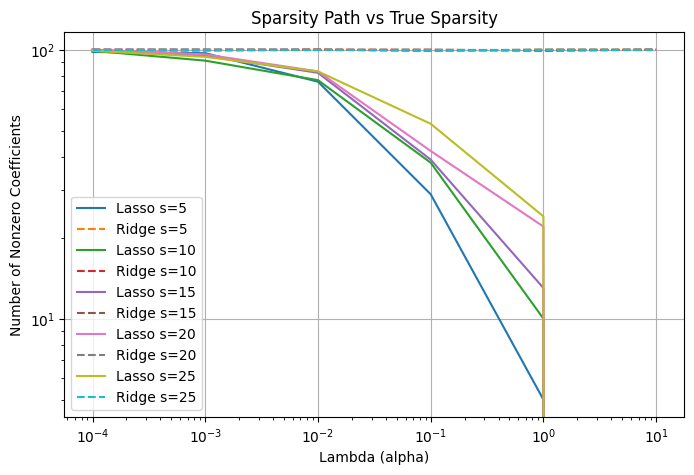

In [9]:
sparsity_values = [5, 10, 15, 20, 25]

alphas=[0.0001, 0.001, 0.01, 0.1, 1, 10]

results = {}

for sparsity in sparsity_values:
    X, y, w_true, non0 = generate_sparse_linear_data(
        n=100, d=100, s=sparsity, sigma=1.0, signal=2.0, random_seeds=20
    )

    lasso_nonzero = []
    ridge_nonzero = []

    for alpha in alphas:
        lasso = Lasso(alpha=alpha)
        lasso.fit(X, y)

        ridge = Ridge(alpha=alpha)
        ridge.fit(X, y)

        lasso_nonzero.append(np.sum(np.abs(lasso.coef_) > 1e-3))
        ridge_nonzero.append(np.sum(np.abs(ridge.coef_) > 1e-3))

    results[sparsity] = {
        "lasso": lasso_nonzero,
        "ridge": ridge_nonzero
    }

plt.figure(figsize=(8, 5))

for sparsity in sparsity_values:
    plt.plot(alphas, results[sparsity]["lasso"], label=f"Lasso s={sparsity}")
    plt.plot(alphas, results[sparsity]["ridge"], linestyle='--', label=f"Ridge s={sparsity}")

plt.xscale('log')
plt.xlabel("Lambda (alpha)")
plt.yscale('log')
plt.ylabel("Number of Nonzero Coefficients")
plt.title("Sparsity Path vs True Sparsity")

plt.legend()
plt.grid(True)
plt.show()

As regularization increases, Lasso drives many coefficients to zero, while Ridge keeps all coefficients nonzero. This shows that Lasso promotes sparsity, whereas Ridge does not. 

We know lasso is produced using l1-regularization which can produce zeros in the regularization (0) while ridge does not and produces smooth regularization.

# References
- scikit-learn Developers. (n.d.). recall_score.
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html
- Singh, Y. (2022). Precision, Recall, and F1 Score: A Practical Guide Using Scikit-Learn. Proclus Academy.
https://proclusacademy.com/blog/practical/precision-recall-f1-score-sklearn/
- Evidently AI. (2025). Accuracy vs. precision vs. recall in machine learning: what's the difference?
https://www.evidentlyai.com/classification-metrics/accuracy-precision-recall
- DataCamp. (2022). Learning Curves Tutorial: What Are Learning Curves?
https://www.datacamp.com/fr/tutorial/tutorial-learning-curves
- Dataquest. (2018). Tutorial: Learning Curves for Machine Learning in Python for Data Science.
https://www.dataquest.io/blog/learning-curves-machine-learning/
- James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Springer.
- DataCamp. (2022). Lasso and Ridge Regression in Python Tutorial.
https://www.datacamp.com/tutorial/tutorial-lasso-ridge-regression
- Bhuva, L. (2025). Understanding the Bias-Variance Tradeoff and Regularization in Machine Learning. Medium.
https://medium.com/@lomashbhuva/understanding-the-bias-variance-tradeoff-and-regularization-in-machine-learning-cdc5dd5e260e